# 🧠 Complete CNN (Convolutional Neural Network) — In-Depth Guide with Numerical Examples

> **Goal:** Understand exactly how a CNN works internally — step by step, with shapes, numbers, and one detailed running example throughout.

---

# 📌 Our Running Example (Used Throughout This Entire Notebook)

We will use **one image** throughout this entire notebook:

- **Input:** A **5×5 Grayscale Image** (like a tiny picture of a digit "7")
- **Task:** Classify it as a digit

```
Input Image (5×5 pixels, 1 channel):
┌─────────────────────────┐
│  1   0   1   0   1     │
│  0   1   0   1   0     │
│  1   1   1   1   1     │
│  0   0   1   0   0     │
│  0   0   1   0   0     │
└─────────────────────────┘
Shape: (5, 5, 1)
```

---

# 1. Introduction to CNN

## 1.1 What is CNN?

A **Convolutional Neural Network (CNN)** is a type of deep learning model designed specifically to work with **grid-like data** — especially images.

The word "convolutional" comes from a mathematical operation called **convolution**, which is the core operation that makes CNNs powerful.

CNNs **automatically learn to detect features** like edges, shapes, textures, and objects directly from raw pixel values — without you manually engineering features.

**Key Idea:**
> Instead of looking at an entire image at once, CNN uses small filters/windows that slide over the image and extract patterns locally. These local patterns are combined in deeper layers to understand global structure.

## 1.2 Why CNN is Used for Images

Consider a **224×224 RGB image**:
- Total pixels = 224 × 224 × 3 = **150,528 values**

If you use a traditional ANN (fully connected):
- Every neuron connects to all 150,528 inputs
- With 1000 neurons in layer 1 → **150 million parameters** in just ONE layer
- **Problem:** Too many parameters → overfitting, slow training, memory explosion

CNN solves this with:
| Technique | How it helps |
|-----------|-------------|
| **Local connectivity** | Each filter only looks at a small region (e.g., 3×3) |
| **Weight sharing** | Same filter is reused across the entire image |
| **Pooling** | Reduces spatial size, fewer parameters |

**Result:** CNN on same image might use only **60,000 parameters** — 2500× fewer!

## 1.3 Difference Between ANN and CNN

| Feature | ANN (Fully Connected) | CNN |
|---------|----------------------|-----|
| Input structure | Flat vector | 2D/3D grid (H×W×C) |
| Connections | Every neuron to every neuron | Local filters (3×3, 5×5) |
| Parameters | Huge (millions) | Shared (much fewer) |
| Spatial awareness | ❌ No | ✅ Yes |
| Translation invariance | ❌ No | ✅ Yes (same feature detected anywhere) |
| Best for | Tabular data | Images, video, spatial data |

---

# 2. Image Input Basics

## 2.1 Pixels

A **pixel** is the smallest unit of an image. Each pixel has a numeric intensity value.

- **Grayscale image:** Each pixel = 1 number between `0` (black) and `255` (white)
- **Color (RGB) image:** Each pixel = 3 numbers `[R, G, B]` each between `0–255`

**Example: A 3×3 grayscale patch:**
```
150  200  100
 50  255   80
  0  130  210
```

After normalization (÷255):
```
0.59  0.78  0.39
0.20  1.00  0.31
0.00  0.51  0.82
```

## 2.2 Image Dimensions (Height × Width × Channels)

Every image in CNN is represented as a **3D tensor:**
```
Shape = (Height, Width, Channels)
```

| Image Type | Example Shape |
|-----------|--------------|
| Grayscale | (28, 28, 1) |
| RGB Color | (224, 224, 3) |
| Our Example | (5, 5, 1) |

**A batch of 32 images is:**
```
Shape = (32, 5, 5, 1)
         ↑    ↑  ↑  ↑
      batch  H  W  C
```

## 2.3 RGB and Grayscale Images

**Grayscale:**
```
[[100, 150, 200],
 [ 50,  80,  60],
 [180,  90,  30]]
Shape: (3, 3, 1)
```

**RGB (same image in color):**
```
Red channel:   [[100, 120, 200], ...]
Green channel: [[ 80,  90, 150], ...]
Blue channel:  [[ 50,  60, 100], ...]
Shape: (3, 3, 3)
```

**Why grayscale for our example?**  
Simpler to follow — only 1 channel. Everything works the same way for RGB, just applied to each channel.

---

# 3. Convolution Layer — The Heart of CNN

## 3.1 What is Convolution?

Convolution is a **mathematical sliding operation** where a small matrix (filter/kernel) moves across the input image and at each position computes a **dot product** between the filter values and the image values under it.

**Intuition:** Think of a filter as a "detector." When the pattern in the image matches the filter pattern, the dot product gives a **high value** (strong activation). When they don't match, it gives a **low value**.

## 3.2 Filters / Kernels

A **filter** (also called a kernel) is a small matrix of learnable weights.

**Example — A 3×3 Vertical Edge Detection Filter:**
```
Filter:
┌─────────────┐
│  1   0  -1  │
│  1   0  -1  │
│  1   0  -1  │
└─────────────┘
```

This filter fires (gives high output) when it sees a **vertical edge** — bright pixels on left, dark pixels on right.

**Filter Properties:**
- Size: typically 3×3 or 5×5
- Depth must match input channels (for grayscale: depth=1, for RGB: depth=3)
- Values are **learned** during training via backpropagation

## 3.3 How Filters Slide Over Images

The filter starts at the **top-left corner**, computes the dot product, then **slides** to the right by `stride` pixels. When it reaches the end of a row, it moves down and starts from the left again.

```
Step 1: Filter at position (0,0)        Step 2: Filter at position (0,1)
                                        
Image patch:   Filter:                  Image patch:   Filter:
1  0  1        1  0 -1                  0  1  0        1  0 -1
0  1  0   ⊗    1  0 -1    = result      1  0  1   ⊗    1  0 -1   = result
1  1  1        1  0 -1                  1  1  1        1  0 -1

The ⊗ symbol means: element-wise multiply then sum all values
```

## 3.4 Feature Extraction

Each filter **extracts a specific feature** from the image. The output of applying a filter to the entire image is called a **Feature Map** (or activation map).

- 1 filter → 1 feature map
- 32 filters → 32 feature maps
- Each feature map says: "How strongly does this feature appear at each location?"

## 3.5 Edge Detection Example — Fully Numerical

Let's use our 5×5 input image and a 3×3 filter.

**Input Image (5×5):**
```
X =
1  0  1  0  1
0  1  0  1  0
1  1  1  1  1
0  0  1  0  0
0  0  1  0  0
```

**Filter (3×3) — Vertical Edge Detector:**
```
K =
 1   0  -1
 1   0  -1
 1   0  -1
```

**Computing Output at Position (0,0):**

Extract the 3×3 patch from image at top-left:
```
Patch:          Filter:         Element-wise product:
1  0  1         1   0  -1       1×1   0×0   1×(-1)   =  1  0  -1
0  1  0    ×    1   0  -1  →    0×1   1×0   0×(-1)   =  0  0   0
1  1  1         1   0  -1       1×1   1×0   1×(-1)   =  1  0  -1

Sum = 1+0+(-1)+0+0+0+1+0+(-1) = 0
```

**Computing Output at Position (0,1):**

Extract the 3×3 patch starting at column 1:
```
Patch:          Filter:         Element-wise product:
0  1  0         1   0  -1       0×1   1×0   0×(-1)   =  0  0   0
1  0  1    ×    1   0  -1  →    1×1   0×0   1×(-1)   =  1  0  -1
1  1  1         1   0  -1       1×1   1×0   1×(-1)   =  1  0  -1

Sum = 0+0+0+1+0+(-1)+1+0+(-1) = 0
```

**Computing Output at Position (0,2):**
```
Patch:          Filter:         Element-wise product:
1  0  1         1   0  -1       1×1   0×0   1×(-1)   =  1  0  -1
0  1  0    ×    1   0  -1  →    0×1   1×0   0×(-1)   =  0  0   0
1  1  1         1   0  -1       1×1   1×0   1×(-1)   =  1  0  -1

Sum = 1+0+(-1)+0+0+0+1+0+(-1) = 0
```

**Computing all positions — Output Feature Map:**

With a 5×5 input and 3×3 filter (no padding, stride=1):
Output size = (5-3)/1 + 1 = **3×3**

```
Full Output Feature Map:
Position (0,0) = 0
Position (0,1) = 0
Position (0,2) = 0
Position (1,0) = -1
Position (1,1) = 0
Position (1,2) = 1
Position (2,0) = 0
Position (2,1) = 0
Position (2,2) = 0

Output Feature Map:
┌──────────────┐
│  0   0   0  │
│ -1   0   1  │
│  0   0   0  │
└──────────────┘
Shape: (3, 3, 1)
```

> **Interpretation:** Positive values = vertical edge with bright-left/dark-right. Negative values = vertical edge with dark-left/bright-right. Zero = no vertical edge.

## 3.6 Output Feature Map Size Formula

```
Output_Height = (Input_Height - Filter_Height + 2×Padding) / Stride + 1
Output_Width  = (Input_Width  - Filter_Width  + 2×Padding) / Stride + 1
```

**Our example:** (5 - 3 + 0) / 1 + 1 = **3**
So output shape = **(3, 3)**

---

# 4. Filter Concepts

## 4.1 Size of Filters (3×3, 5×5, etc.)

| Filter Size | Receptive Field | Use Case | Parameters |
|------------|----------------|----------|------------|
| 1×1 | 1 pixel | Channel mixing, dimensionality reduction | Very few |
| 3×3 | 3×3 region | Most common, good for local features | 9 weights |
| 5×5 | 5×5 region | Larger patterns | 25 weights |
| 7×7 | 7×7 region | Very large patterns (used in first layer) | 49 weights |

**Why 3×3 is most popular:**
- Two stacked 3×3 layers = same receptive field as one 5×5 layer
- But 2×(3×3×C) = 18C parameters vs 5×5×C = 25C parameters
- **Fewer parameters, more non-linearity, better learning**

## 4.2 Number of Filters

You can use **multiple filters** in a single convolution layer. Each filter learns to detect a different feature.

**Example:** If we use **2 filters** on our 5×5 input:
```
Input: (5, 5, 1)
Filter 1 (vertical edges) → Feature Map 1: (3, 3)
Filter 2 (horizontal edges) → Feature Map 2: (3, 3)

Stacked output: (3, 3, 2)   ← 2 is the number of filters
```

**General rule:**
- More filters → More features detected → More expressive model
- But more filters → More computation
- Typical values: 32, 64, 128, 256, 512

## 4.3 Learning Filter Values

Initially, filter values are set **randomly** (e.g., from a normal distribution).

During training:
1. A forward pass computes predictions
2. Loss is calculated (how wrong the predictions are)
3. **Backpropagation** computes the gradient of loss with respect to each filter weight
4. **Gradient descent** updates the filter weights to reduce loss

After thousands of training iterations, filters **self-organize** to detect meaningful patterns.

**Nobody manually designs the filters — the network learns them!**

## 4.4 What Different Filters Detect

### Edges
```
Vertical edge filter:     Horizontal edge filter:
 1   0  -1                 1   1   1
 1   0  -1                 0   0   0
 1   0  -1                -1  -1  -1
```
Fires when there's a transition from light→dark (or dark→light) along an axis.

### Curves
Learned in layer 2 by combining edge detectors. A curve = a series of edges at slightly different angles.

### Textures
Repeated patterns (like fur, grass, brickwork). Detected in mid-level layers by combining curve and edge responses.

### Shapes
Combinations of curves and edges — rectangles, circles, triangles. Detected in deeper layers.

---

# 5. Stride

## 5.1 What Stride Means

**Stride** is the number of pixels the filter moves at each step.

- **Stride = 1:** Move 1 pixel at a time (default, most detail preserved)
- **Stride = 2:** Move 2 pixels at a time (output is roughly half the size)

## 5.2 Stride = 1 (Detailed Example)

**Input (5×5), Filter (3×3), Stride = 1:**

```
Step 1: cols 0-2     Step 2: cols 1-3     Step 3: cols 2-4
┌───────┐            ┌───────┐            ┌───────┐
│X X X  │            │ X X X │            │  X X X│
│X X X  │            │ X X X │            │  X X X│
│X X X  │            │ X X X │            │  X X X│
└───────┘            └───────┘            └───────┘
↓ moves 1 right ↓    ↓ moves 1 right ↓
```

Output size = (5 - 3)/1 + 1 = **3** positions horizontally
Full output: **(3, 3)**

## 5.3 Stride = 2 (Detailed Example)

**Same input, Stride = 2:**

```
Step 1: cols 0-2     Step 2: cols 2-4   (jumps 2)
┌───────┐            ┌───────┐
│X X X  │            │  X X X│
│X X X  │            │  X X X│
│X X X  │            │  X X X│
└───────┘            └───────┘
```

Output size = (5 - 3)/2 + 1 = **2** positions horizontally
Full output: **(2, 2)** — smaller!

## 5.4 Effect on Output Size

| Input | Filter | Stride | Output Size |
|-------|--------|--------|------------|
| 5×5 | 3×3 | 1 | 3×3 |
| 5×5 | 3×3 | 2 | 2×2 |
| 8×8 | 3×3 | 1 | 6×6 |
| 8×8 | 3×3 | 2 | 3×3 |
| 32×32 | 5×5 | 1 | 28×28 |

**Formula:** `Output = floor((Input - Filter) / Stride) + 1`

---

# 6. Padding

## 6.1 Why Padding is Needed

**Problem without padding:**
- After each convolution, the output shrinks
- With many layers, the image becomes too small
- Pixels at the **edges/corners** are covered by fewer filter positions → **edge information is underrepresented**

```
5×5 input → 3×3 conv → 3×3 output   (lost 2 pixels in each dimension)
3×3 output → 3×3 conv → 1×1 output  (lost everything!)
```

**Solution:** Add a border of zeros around the image before convolution.

## 6.2 Same Padding

Pad the input so that the **output has the same spatial size as the input**.

**Formula for padding amount:**
```
p = (Filter_Size - 1) / 2

For 3×3 filter: p = (3-1)/2 = 1 (add 1 pixel border)
For 5×5 filter: p = (5-1)/2 = 2 (add 2 pixel border)
```

**Our example with Same Padding (p=1):**

Original 5×5 input padded to 7×7:
```
Padded Input (7×7):
0  0  0  0  0  0  0
0  1  0  1  0  1  0
0  0  1  0  1  0  0
0  1  1  1  1  1  0
0  0  0  1  0  0  0
0  0  0  1  0  0  0
0  0  0  0  0  0  0
```

Now apply 3×3 filter → Output = **(5, 5)** — same as input! ✅

## 6.3 Valid Padding

**No padding at all** — filter only placed where it fully fits inside the image.

```
Output size = Input - Filter + 1
5×5 input, 3×3 filter → 3×3 output
```

This is called "valid" because every filter position uses only valid (real) pixels.

## 6.4 Zero Padding Examples

```
Original 3×3:       With p=1 (5×5):     With p=2 (7×7):
1  2  3             0  0  0  0  0        0  0  0  0  0  0  0
4  5  6     →       0  1  2  3  0   →    0  0  0  0  0  0  0
7  8  9             0  4  5  6  0        0  0  1  2  3  0  0
                    0  7  8  9  0        0  0  4  5  6  0  0
                    0  0  0  0  0        0  0  7  8  9  0  0
                                         0  0  0  0  0  0  0
                                         0  0  0  0  0  0  0
```

---

# 7. Activation Function

## 7.1 Why Activation is Needed

Convolution is a **linear operation** — it's just multiplication and addition.

If you stack multiple linear layers:
```
Layer 2(Layer 1(x)) = Layer2(W1·x + b1) = W2·(W1·x + b1) + b2
                    = (W2·W1)·x + (W2·b1 + b2)
                    = W_combined · x + b_combined
```

**Multiple linear layers = still just one linear transformation!**

You lose all the power of depth. The network can only learn **straight-line boundaries** — cannot detect complex, curved, non-linear features.

**Solution:** Apply a non-linear activation function after each convolution.

## 7.2 ReLU (Rectified Linear Unit)

**Formula:**
```
ReLU(x) = max(0, x)
```

**Graph:**
```
Output
  |          /
  |         /
  |        /
  |_______/___________  Input
          0
```

- If input > 0: output = input (passes through unchanged)
- If input ≤ 0: output = 0 (killed)

**Why ReLU?**
- Computationally extremely fast (just a comparison)
- Solves the "vanishing gradient" problem
- Sparsity: negative activations become zero → only important features "fire"
- Proven to work well in practice

**Other activations:**
- `Sigmoid`: σ(x) = 1/(1+e^(-x)) → output between 0 and 1
- `Tanh`: output between -1 and 1
- `Leaky ReLU`: small negative slope instead of 0 for negatives

## 7.3 How ReLU Removes Negative Values — Numerical Example

**Input Feature Map (after convolution):**
```
After Conv:           After ReLU:
 0   0   0            0   0   0
-1   0   1    →       0   0   1
 0   0   0            0   0   0
```

The `-1` value (dark-to-bright edge in other direction) is suppressed to 0. Only the positive (bright-to-dark) edge response survives.

**This makes the network focus only on the presence of features, not their direction.**

**Full numerical trace of our example after ReLU:**
```
Input to this stage (from convolution):
 0   0   0
-1   0   1
 0   0   0

ReLU applied element-wise:
max(0, 0)  = 0    max(0, 0) = 0    max(0, 0)  = 0
max(0,-1)  = 0    max(0, 0) = 0    max(0, 1)  = 1
max(0, 0)  = 0    max(0, 0) = 0    max(0, 0)  = 0

After ReLU Feature Map:
0  0  0
0  0  1
0  0  0
Shape: (3, 3, 1)  ← Shape unchanged! ReLU doesn't change dimensions
```

---

# 8. Pooling Layer

## 8.1 Why Pooling is Used

After convolution + ReLU, the feature maps still contain a lot of spatial information. Pooling:

1. **Reduces spatial dimensions** → fewer parameters, faster computation
2. **Creates translation invariance** → a feature is detected even if it shifts slightly
3. **Reduces overfitting** → less data to memorize

**Translation invariance example:**
```
Without pooling: Feature at pixel (5,7) ≠ feature at pixel (5,8)
With max pooling: Both map to the same pooling cell → treated as same feature
```

## 8.2 Max Pooling — Detailed Numerical Example

**Max Pooling:** Take the **maximum value** in each pooling window.

**Input (4×4 feature map):**
```
1  3  2  4
5  6  1  2
3  2  1  0
1  2  3  4
```

**Pool size = 2×2, Stride = 2:**

```
Window 1 (rows 0-1, cols 0-1):    Window 2 (rows 0-1, cols 2-3):
1  3                               2  4
5  6   → max = 6                   1  2   → max = 4

Window 3 (rows 2-3, cols 0-1):    Window 4 (rows 2-3, cols 2-3):
3  2                               1  0
1  2   → max = 3                   3  4   → max = 4
```

**Max Pooling Output (2×2):**
```
6  4
3  4
```

**Output shape:** (4-2)/2 + 1 = **2** → Shape: **(2, 2)**

> **Insight:** Max pooling keeps the **most activated** (most prominent) feature in each region, discarding exact location.

## 8.3 Average Pooling

**Average Pooling:** Take the **mean value** in each window.

Same 4×4 input:
```
Window 1: (1+3+5+6)/4 = 15/4 = 3.75
Window 2: (2+4+1+2)/4 =  9/4 = 2.25
Window 3: (3+2+1+2)/4 =  8/4 = 2.00
Window 4: (1+0+3+4)/4 =  8/4 = 2.00
```

**Average Pooling Output:**
```
3.75  2.25
2.00  2.00
```

**Max vs Average:**
| | Max Pooling | Average Pooling |
|--|------------|----------------|
| Keeps | Most prominent feature | Average presence |
| Good for | Detecting feature exists | Retaining background context |
| Most common | ✅ Yes (default choice) | Used in Global Average Pooling |

## 8.4 Pool Size

Most common: **2×2** with stride 2

- Pool 2×2, stride 2: Each dimension halved → (H/2, W/2)
- Pool 3×3, stride 3: Each dimension ÷3 → (H/3, W/3)

## 8.5 Effect on Dimensions

**Applying 2×2 Max Pooling to our example:**

After ReLU, feature map was (3, 3):
```
0  0  0
0  0  1
0  0  0
```

Pool size=2×2, stride=2 on a 3×3 map:
- Position (0,0): max(0,0,0,0) = **0**
- Position (0,1): only fits partially... 

**Note:** 3×3 with 2×2 pool, stride=2:
```
Output size = floor((3-2)/2) + 1 = floor(0.5) + 1 = 1
So output is (1, 1)
```

For better illustration, let's imagine our feature map from 2 filters is (3, 3, 2). After 2×2 pooling with stride=2:
```
Shape: (3, 3, 2) → (1, 1, 2)
```

**In real networks** (larger images like 32×32):
```
(32, 32, 32) → pool 2×2 → (16, 16, 32)
(16, 16, 64) → pool 2×2 → (8, 8, 64)
(8, 8, 128)  → pool 2×2 → (4, 4, 128)
```

---

# 9. Multiple Convolution + Pooling Layers (Deep Features)

## 9.1–9.3 Hierarchical Feature Learning

The deeper the layer, the more **abstract and complex** the features detected.

```
┌─────────────────────────────────────────────────────────────────┐
│                    HIERARCHICAL FEATURES                        │
├───────────────┬─────────────────────────────────────────────────┤
│ Layer 1       │ Low-level: edges (horizontal, vertical,         │
│ (Conv+Pool)   │ diagonal), color blobs, gradients              │
├───────────────┼─────────────────────────────────────────────────┤
│ Layer 2       │ Mid-level: corners, curves, circles,           │
│ (Conv+Pool)   │ arcs, simple textures                          │
├───────────────┼─────────────────────────────────────────────────┤
│ Layer 3       │ Higher-level: eyes, mouth, wheels, paws,       │
│ (Conv+Pool)   │ windows, patterns                              │
├───────────────┼─────────────────────────────────────────────────┤
│ Layer 4       │ Semantic: full face, car body, animal,         │
│ (Conv+Pool)   │ building — object parts                        │
└───────────────┴─────────────────────────────────────────────────┘
```

**Why does this happen?**

Layer 2 filters take Layer 1 feature maps as input. So they learn "where do edges combine to form curves?" Layer 3 filters take Layer 2 output and learn "where do curves combine to form eyes?"

This is **automatic hierarchical feature learning** — it happens organically through backpropagation.

**Numerical trace (conceptual):**
```
Original pixel:     1  0  1  0  1  ...
                    ↓ Layer 1 Conv+ReLU+Pool
Edge responses:     0.9  0.1  0.8  ...  (edge present at position)
                    ↓ Layer 2 Conv+ReLU+Pool
Curve responses:    0.7  0.0  0.6  ...  (curve present)
                    ↓ Layer 3 Conv+ReLU+Pool
Eye detector:       0.9 ...             (eye detected!)
                    ↓ Layer 4 Conv+ReLU+Pool
Face detector:      0.85 ...            (face detected!)
```

---

# 10. Flattening Layer

## 10.1 Why Flattening is Needed

After several Conv+Pool layers, we have a **3D feature map** like `(4, 4, 64)`.

The final classification step (Fully Connected layer) needs a **1D vector** as input — it can't take a 3D grid.

**Flattening simply unrolls the 3D tensor into a 1D vector.** No computation, no parameters — just reshaping.

## 10.2 Converting Matrix to Vector

```
3D Tensor: (H, W, C)  →  1D Vector of length H × W × C
```

## 10.3 Example Conversion — Numerical

**After all convolutions and pooling, suppose we have:**
```
Feature Map Shape: (2, 2, 2)   ← 2 feature maps, each 2×2

Feature Map 1 (from filter 1):     Feature Map 2 (from filter 2):
0.8   0.0                           0.5   0.1
0.0   0.3                           0.9   0.0
```

**Flatten** — reading values row by row, map by map:
```
Feature Map 1: [0.8, 0.0, 0.0, 0.3]
Feature Map 2: [0.5, 0.1, 0.9, 0.0]

Concatenated 1D vector:
[0.8, 0.0, 0.0, 0.3, 0.5, 0.1, 0.9, 0.0]

Shape: (8,)  = 2×2×2 = 8 values
```

> **Important:** No information is lost during flattening! Just reorganized.

---

# 11. Fully Connected Layer

## 11.1 Dense Layer

A **Fully Connected (FC)** or **Dense** layer connects **every neuron** to every neuron in the next layer. This is the classic neural network layer.

```
Input vector: [0.8, 0.0, 0.0, 0.3, 0.5, 0.1, 0.9, 0.0]
                  ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓  (all connected)
Output:            [node1, node2, ..., node_N]
```

**Computation:**
```
output[j] = activation( Σ(input[i] × weight[i,j]) + bias[j] )
```

## 11.2 Combining Learned Features

The FC layer takes the **encoded features from all the conv layers** (now in a flat vector) and learns **which combination of features predicts which class.**

For example:
```
"If large edge response at top + curve in middle + blob at bottom 
 → probably the digit '7'"
```

This is learned automatically through training.

## 11.3 Classification Process — Numerical

**Flattened input vector:**
```
x = [0.8, 0.0, 0.0, 0.3, 0.5, 0.1, 0.9, 0.0]
```

**Weight matrix (8 inputs → 4 output neurons):**
```
W = [[0.2,  0.5,  0.1,  0.8],
     [0.3, -0.1,  0.4,  0.2],
     [0.1,  0.9, -0.2,  0.3],
     [0.4,  0.2,  0.6, -0.1],
     [0.7,  0.1,  0.3,  0.5],
     [0.2,  0.4,  0.1,  0.6],
     [0.9,  0.3,  0.2,  0.4],
     [0.1,  0.5,  0.8,  0.2]]

bias = [0.1, 0.1, 0.1, 0.1]
```

**Computing output of neuron 1 (class 0):**
```
z1 = x · W[:,0] + b[0]
   = 0.8×0.2 + 0.0×0.3 + 0.0×0.1 + 0.3×0.4 + 0.5×0.7 + 0.1×0.2 + 0.9×0.9 + 0.0×0.1 + 0.1
   = 0.16 + 0 + 0 + 0.12 + 0.35 + 0.02 + 0.81 + 0 + 0.1
   = 1.56

Apply ReLU: max(0, 1.56) = 1.56
```

Do this for all 4 neurons → get a vector of 4 values.

---

# 12. Output Layer

## 12.1 Softmax

The final layer uses **Softmax** to convert raw scores (called **logits**) into **probabilities**.

**Formula:**
```
Softmax(z_i) = e^(z_i) / Σ(e^(z_j))   for all j
```

This guarantees:
- Each output is between 0 and 1
- All outputs sum to exactly 1.0
- Interpretable as probabilities

## 12.2 Probability Prediction — Numerical

**Suppose the 4 class logits (raw scores) are:**
```
z = [2.1, 0.5, 1.3, 0.8]
     ↑     ↑    ↑    ↑
   class0 class1 class2 class3
```

**Step 1: Compute exponentials:**
```
e^2.1 = 8.166
e^0.5 = 1.649
e^1.3 = 3.669
e^0.8 = 2.226
Sum   = 15.71
```

**Step 2: Divide each by sum:**
```
P(class 0) = 8.166 / 15.71 = 0.520  → 52.0%
P(class 1) = 1.649 / 15.71 = 0.105  → 10.5%
P(class 2) = 3.669 / 15.71 = 0.234  → 23.4%
P(class 3) = 2.226 / 15.71 = 0.142  → 14.2%
                               ─────
                               100.0% ✅
```

## 12.3 Final Class Selection

Take the **argmax** — the class with the highest probability:

```
Predicted class = argmax([0.520, 0.105, 0.234, 0.142])
                = class 0 (with 52.0% confidence)
```

---

# 13. Complete CNN Flow — End to End with Our Example

```
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STAGE 1: INPUT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input image:
  1  0  1  0  1
  0  1  0  1  0
  1  1  1  1  1
  0  0  1  0  0
  0  0  1  0  0

Shape: (5, 5, 1)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STAGE 2: CONV LAYER 1 (3×3 filter, 1 filter, stride=1, no padding)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Filter:
   1   0  -1
   1   0  -1
   1   0  -1

Output feature map:
   0   0   0
  -1   0   1
   0   0   0

Shape: (3, 3, 1)   [from (5,5,1) → reduced to (3,3,1)]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STAGE 3: RELU ACTIVATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input:            After ReLU (max(0,x)):
   0   0   0         0   0   0
  -1   0   1    →    0   0   1
   0   0   0         0   0   0

Shape: (3, 3, 1)   [unchanged]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STAGE 4: MAX POOLING (2×2, stride=2)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input (3×3):       Only 1 window fits fully (2×2, stride=2):
  0  0  0
  0  0  1    →    max(0,0,0,0) = 0
  0  0  0

Output: [[0]]
Shape: (1, 1, 1)

Note: In real use, images are much larger (e.g. 32×32 → 16×16 after pooling)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STAGE 5: FLATTEN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input tensor: [[[0]]]   Shape: (1, 1, 1)
Flattened:    [0]        Shape: (1,)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STAGE 6: FULLY CONNECTED LAYER
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input: [0.0]
Weights (1 input → 4 classes): [0.2, 0.9, 0.3, 0.5]
Bias: [0.1, 0.1, 0.1, 0.1]

output = 0.0 × W + b = [0.1, 0.1, 0.1, 0.1]
After ReLU: [0.1, 0.1, 0.1, 0.1]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STAGE 7: OUTPUT (SOFTMAX)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Logits: [0.1, 0.1, 0.1, 0.1]
Softmax: e^0.1 for all → equal → [0.25, 0.25, 0.25, 0.25]
                                    25%   25%   25%   25%

(Uniform — because weights are not yet trained!)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FULL SHAPE SUMMARY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input           →  (5, 5, 1)
After Conv1     →  (3, 3, 1)
After ReLU1     →  (3, 3, 1)
After Pool1     →  (1, 1, 1)
After Flatten   →  (1,)
After FC Layer  →  (4,)
After Softmax   →  (4,)   ← 4 class probabilities
```

---

# 14. Training Process (After Understanding Architecture)

## 14.1 Forward Propagation

**Forward propagation** is everything we just did above — passing the input through all layers from left to right to get a prediction.

```
Input → Conv → ReLU → Pool → ... → FC → Softmax → Prediction
```

The prediction is compared to the **true label** to compute the error.

## 14.2 Loss Calculation

**Loss (or cost) function** measures how wrong the prediction is.

For classification, we use **Cross-Entropy Loss:**

```
Loss = -Σ(y_true × log(y_predicted))
```

**Numerical example:**

True label: class 0 (digit "1")
True label vector (one-hot): `[1, 0, 0, 0]`
Predicted probabilities: `[0.70, 0.10, 0.15, 0.05]`

```
Loss = -(1×log(0.70) + 0×log(0.10) + 0×log(0.15) + 0×log(0.05))
     = -(1 × log(0.70))
     = -(1 × (-0.357))
     = 0.357
```

**If prediction was perfect (`[1.0, 0, 0, 0]`):**
```
Loss = -(1 × log(1.0)) = -(1 × 0) = 0
```

Lower loss = better prediction.

## 14.3 Backpropagation

**Backpropagation** computes how much each weight in the network contributed to the error, using the **chain rule** of calculus.

The chain rule says: to find how weight `w` in layer 1 affects the final loss, multiply the gradients all the way from loss back to that layer.

```
∂Loss/∂w₁ = ∂Loss/∂ŷ × ∂ŷ/∂z_fc × ∂z_fc/∂a_pool × ... × ∂conv_out/∂w₁
             ─────────────────────────────────────────────────────────────
             Chain of partial derivatives through every layer
```

**Key gradients:**
```
For Softmax + Cross-Entropy: ∂Loss/∂z = ŷ - y  (very clean formula!)
For ReLU:  ∂/∂x = 1 if x > 0, else 0
For Conv:  gradient flows back through the filter weights
```

**Backprop gives us a gradient vector** — the direction and magnitude to change every weight to reduce the loss.

## 14.4 Weight Updates

Once we have gradients, we update all weights using **Gradient Descent:**

```
w_new = w_old - learning_rate × gradient

Example:
w_old = 0.5
gradient = 0.3   (loss increases if w increases)
learning_rate = 0.01

w_new = 0.5 - 0.01 × 0.3 = 0.5 - 0.003 = 0.497
```

The learning rate controls how big each step is:
- Too large → weights oscillate, training unstable
- Too small → training very slow
- Typical values: 0.001, 0.0001

**Modern optimizers** (Adam, RMSProp) automatically adjust the effective learning rate per weight.

## 14.5 Epochs

One **epoch** = one pass through the **entire training dataset** (forward + backward + weight update for every sample).

```
Epoch 1:  loss = 2.31  (random weights, terrible prediction)
Epoch 5:  loss = 1.85  (starting to learn basic features)
Epoch 10: loss = 1.20  (learning edges, basic shapes)
Epoch 25: loss = 0.62  (good feature representations)
Epoch 50: loss = 0.28  (high accuracy)
Epoch 100: loss = 0.08  (very high accuracy)
```

In practice:
- We use **mini-batches** (e.g., 32 or 64 images at once) for efficiency
- One epoch = (total_samples / batch_size) weight updates

```
10,000 images, batch size 32:
Updates per epoch = 10,000 / 32 ≈ 312 weight updates
```

---

# 🔁 Complete Picture: Architecture + Training Loop

```
┌─────────────────────────────────────────────────────────────────────────┐
│                     CNN TRAINING LOOP                                    │
│                                                                          │
│  ┌──────────┐     ┌──────────┐     ┌──────────┐     ┌──────────┐      │
│  │  Input   │────▶│   Conv   │────▶│   ReLU   │────▶│ Pooling  │──┐   │
│  │  Image   │     │  Layer   │     │          │     │  Layer   │  │   │
│  └──────────┘     └──────────┘     └──────────┘     └──────────┘  │   │
│       ▲                                                              │   │
│       │                                                ┌────────────┘   │
│  WEIGHT UPDATE                                         ▼                │
│  (Gradient Descent)                          ┌─────────────────┐        │
│       │                                      │ More Conv+Pool  │        │
│       │                                      │    Layers?      │        │
│  ┌────┴──────┐                               └────────┬────────┘        │
│  │  LOSS     │                                        ▼                │
│  │Calculation│◀──────── Prediction ◀────────── ┌──────────────┐       │
│  └────┬──────┘                                 │   Flatten    │       │
│       │                                        └──────┬───────┘       │
│  BACKPROPAGATION                                      ▼               │
│  (Chain Rule)                                  ┌──────────────┐       │
│       └──────────────────────────────────────▶ │  FC + Softmax│       │
│                                                └──────────────┘       │
└─────────────────────────────────────────────────────────────────────────┘
```

---

# 📊 Full Shape Trace — Real Network Example (CIFAR-10)

This is what a real CNN looks like with a **32×32 RGB image** (CIFAR-10 dataset):

```
Layer               Operation                        Output Shape
─────────────────────────────────────────────────────────────────
Input               RGB image                        (32, 32, 3)
─────────────────────────────────────────────────────────────────
Conv2D              32 filters, 3×3, padding=same    (32, 32, 32)
ReLU                Activation                       (32, 32, 32)
MaxPool             2×2, stride=2                    (16, 16, 32)
─────────────────────────────────────────────────────────────────
Conv2D              64 filters, 3×3, padding=same    (16, 16, 64)
ReLU                Activation                       (16, 16, 64)
MaxPool             2×2, stride=2                    (8, 8, 64)
─────────────────────────────────────────────────────────────────
Conv2D              128 filters, 3×3, padding=same   (8, 8, 128)
ReLU                Activation                       (8, 8, 128)
MaxPool             2×2, stride=2                    (4, 4, 128)
─────────────────────────────────────────────────────────────────
Flatten             Unroll to 1D                     (2048,)
─────────────────────────────────────────────────────────────────
Dense (FC)          256 neurons, ReLU                (256,)
─────────────────────────────────────────────────────────────────
Dense (Output)      10 neurons, Softmax              (10,)
─────────────────────────────────────────────────────────────────
```

**Parameter count:**
```
Conv1: 32 × (3×3×3 + 1)    =  32 × 28    =       896
Conv2: 64 × (3×3×32 + 1)   =  64 × 289   =    18,496
Conv3: 128 × (3×3×64 + 1)  = 128 × 577   =    73,856
Dense1: 2048 × 256 + 256   =              =   524,544
Dense2: 256 × 10 + 10      =              =     2,570
─────────────────────────────────────────────────────
Total:                                         620,362 parameters
```



| Concept | What it does | Key number / formula |
|---------|-------------|---------------------|
| **Convolution** | Detects local patterns | Output = (I-K+2P)/S + 1 |
| **Filter** | Template for a feature | 3×3, 5×5 — learned via backprop |
| **ReLU** | Adds non-linearity | max(0, x) |
| **Max Pool** | Downsamples, translation invariance | Keeps max in window |
| **Deep layers** | Higher-level features | Edges→Curves→Parts→Objects |
| **Flatten** | Converts 3D to 1D | H×W×C values → 1D vector |
| **FC Layer** | Combines features for decision | y = ReLU(Wx + b) |
| **Softmax** | Converts scores to probabilities | e^z_i / Σe^z_j |
| **Loss** | Measures wrongness | Cross-entropy = -Σy·log(ŷ) |
| **Backprop** | Computes gradients | Chain rule through all layers |
| **Weight update** | Improves predictions | w = w - lr × gradient |

---

*End of CNN Complete Guide*  
*All shapes, all math, one running example throughout.*

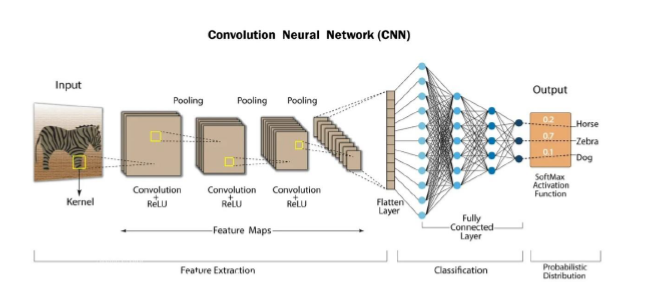
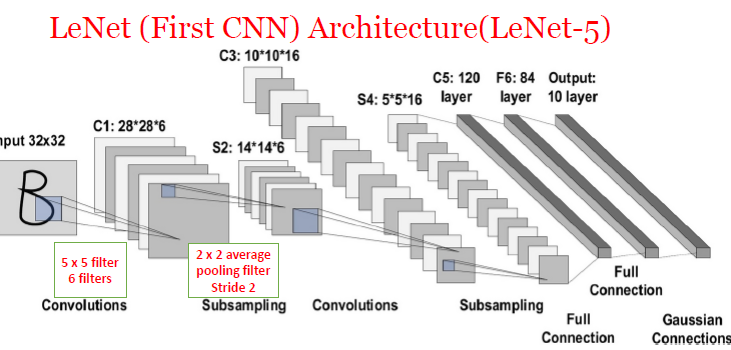